In [ ]:
# --- EXPERIMENT 2: COMPREHENSIVE PENALTY STRENGTH CALIBRATION ---
import sys
import os
import arviz as az


# 1. Force Python to look in the parent directory to find the 'src' folder
sys.path.append(os.path.abspath(os.path.join('..')))

import time
import pandas as pd
import numpy as np
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS, Predictive

# 2. Import your code classes and functions
from src.model import PhylogeneticPrior
from src.diagnostics import evaluate_test_diagnostics
from src.penalty import get_fresh_test_quartets

# 3. DEFINE YOUR VARIABLE CONSTANTS HERE DIRECTLY
N = 50          # Number of taxa/leaves
K = 2           # Latent dimensions 
B_train = 1000  # Number of training quartets used in Experiment 1

# Re-generate the 1000 validation quartets right here in memory
test_quartets = get_fresh_test_quartets(N=N, B_test=1000, seed=123)
# ------------------------------------------------------------------------

# 4. Define the lambda grid loop settings
lmbda_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
experiment_2_results = []

# Baseline hyperparameters frozen from Experiment 1
fixed_sigma_u = 1.0
fixed_tau = 0.1

for lmbda in lmbda_grid:
    print("\n" + "="*80)
    print(f" RUNNING EXPERIMENT 2: lambda = {lmbda} | sigma_u = {fixed_sigma_u} | tau = {fixed_tau}")
    print("="*80)

    pyro.clear_param_store()
    pyro.set_rng_seed(44) # Pinned for absolute reproducibility

    # Instantiate the model with identical training size conditions
    model = PhylogeneticPrior(N=N, K=K, B=B_train, seed=42)

    # Initialize the NUTS sampler kernel with 4 parallel chains
    nuts_kernel = NUTS(model.initialize)
    mcmc = MCMC(
        nuts_kernel, 
        num_samples=1000,    
        warmup_steps=1000,  
        num_chains=4
    )

    # Track execution time
    start_time = time.time()
    mcmc.run(lmbda=lmbda, sigma_u=fixed_sigma_u, tau=fixed_tau)
    elapsed_time = time.time() - start_time

    print(f"--> MCMC Execution complete in {elapsed_time:.2f} seconds.")

    # Extract posterior vector coordinates
    posterior_samples = mcmc.get_samples()

    # Use Predictive to reconstruct full pairwise distance matrices (S, N, N)
    predictive = Predictive(model.initialize, posterior_samples, return_sites=["D"])
    predictive_samples = predictive(lmbda=lmbda, sigma_u=fixed_sigma_u, tau=fixed_tau)
    D_samples = predictive_samples["D"].squeeze(1) if predictive_samples["D"].dim() == 4 else predictive_samples["D"]

    # Compute comprehensive metrics from your diagnostics file
    metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)

    # Collect NUTS diagnostics (Divergent transitions & Acceptance Probabilities)
    sampler_diagnostics = mcmc.diagnostics()
    
    # Extract divergences across all chains
    divergence_list = sampler_diagnostics.get("divergent", [0])
    num_divergences = int(sum(divergence_list))
    
    # Extract average acceptance probability across the chains for NUTS profiling
    acc_probs = sampler_diagnostics.get("accept_prob", [0.0])
    avg_acc_prob = float(np.mean(acc_probs))

   
    
    # 1. Convert the Pyro MCMC object into standard ArviZ InferenceData format
    az_data = az.from_pyro(mcmc)
    
    # 2. Compute summary stats (R-hat and ESS) specifically for your coordinates 'u'
    arviz_summary = az.summary(az_data, var_names=["u"])
    
    # 3. Extract the worst-case scenarios across your 100 parameters to print in the table
    max_r_hat = float(arviz_summary["r_hat"].max())
    min_ess_bulk = float(arviz_summary["ess_bulk"].min())

    # Build the all-inclusive dictionary row explicitly mapping your professor's criteria
    summary_row = {
        "lambda": lmbda,
        "Runtime_(s)": round(elapsed_time, 1),
        "NUTS_Divergences": num_divergences,
        "NUTS_Acc_Prob": round(avg_acc_prob, 3),
        "Violations_Median": round(metrics["hard_violations"]["median"], 4),
        "Violations_95th": round(metrics["hard_violations"]["quantile_95"], 4),
        "Tree_Consistency_Rate": f"{metrics['tree_consistency_rate'] * 100:.2f}%",
        "Quartet_Gap_Median": round(metrics["quartet_gap"]["median"], 4),
        "Star_Fraction_(Unres)": f"{metrics['quartet_gap']['unresolved_fraction'] * 100:.2f}%",
        "Dist_Scale_Min": round(metrics["distance_scale"]["min"], 4),
        "Dist_Scale_Med": round(metrics["distance_scale"]["median"], 4),
        "Dist_Scale_Max": round(metrics["distance_scale"]["max"], 4),
        "Max_R_hat": round(max_r_hat, 3),       
        "Min_ESS": round(min_ess_bulk, 1)
    }
    experiment_2_results.append(summary_row)

# --- Final Output Formatting ---
print("\n" + "#"*100)
print("                               EXPERIMENT 2 COMPLETE RESULTS DISPLAY                               ")
print("#"*100)
df_2 = pd.DataFrame(experiment_2_results)

# Force pandas to print out ALL columns without truncation blocks (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_2.to_string(index=False))
print("#"*100 + "\n")

IndentationError: unexpected indent (866978670.py, line 4)

In [ ]:
# --- Final Output Formatting ---
print("\n" + "#"*100)
print("                               EXPERIMENT 2 COMPLETE RESULTS DISPLAY                               ")
print("#"*100)
df_2 = pd.DataFrame(experiment_2_results)

# Force pandas to print out ALL columns without truncation blocks (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_2.to_string(index=False))
print("#"*100 + "\n")


####################################################################################################
                               EXPERIMENT 2 COMPLETE RESULTS DISPLAY                               
####################################################################################################
 lambda  Runtime_(s)  NUTS_Divergences  NUTS_Acc_Prob  Violations_Median  Violations_95th Tree_Consistency_Rate  Quartet_Gap_Median Star_Fraction_(Unres)  Dist_Scale_Min  Dist_Scale_Med  Dist_Scale_Max  Max_R_hat  Min_ESS
  0.001        126.8                 0            0.0             0.3285           1.0510                12.07%              1.4518                 2.12%          0.0024          3.7038         14.9094       1.74      6.0
  0.010        136.1                 0            0.0             0.3284           1.0563                12.01%              1.4819                 2.06%          0.0005          3.7231         14.8027       2.16      5.0
  0.100         99.5           

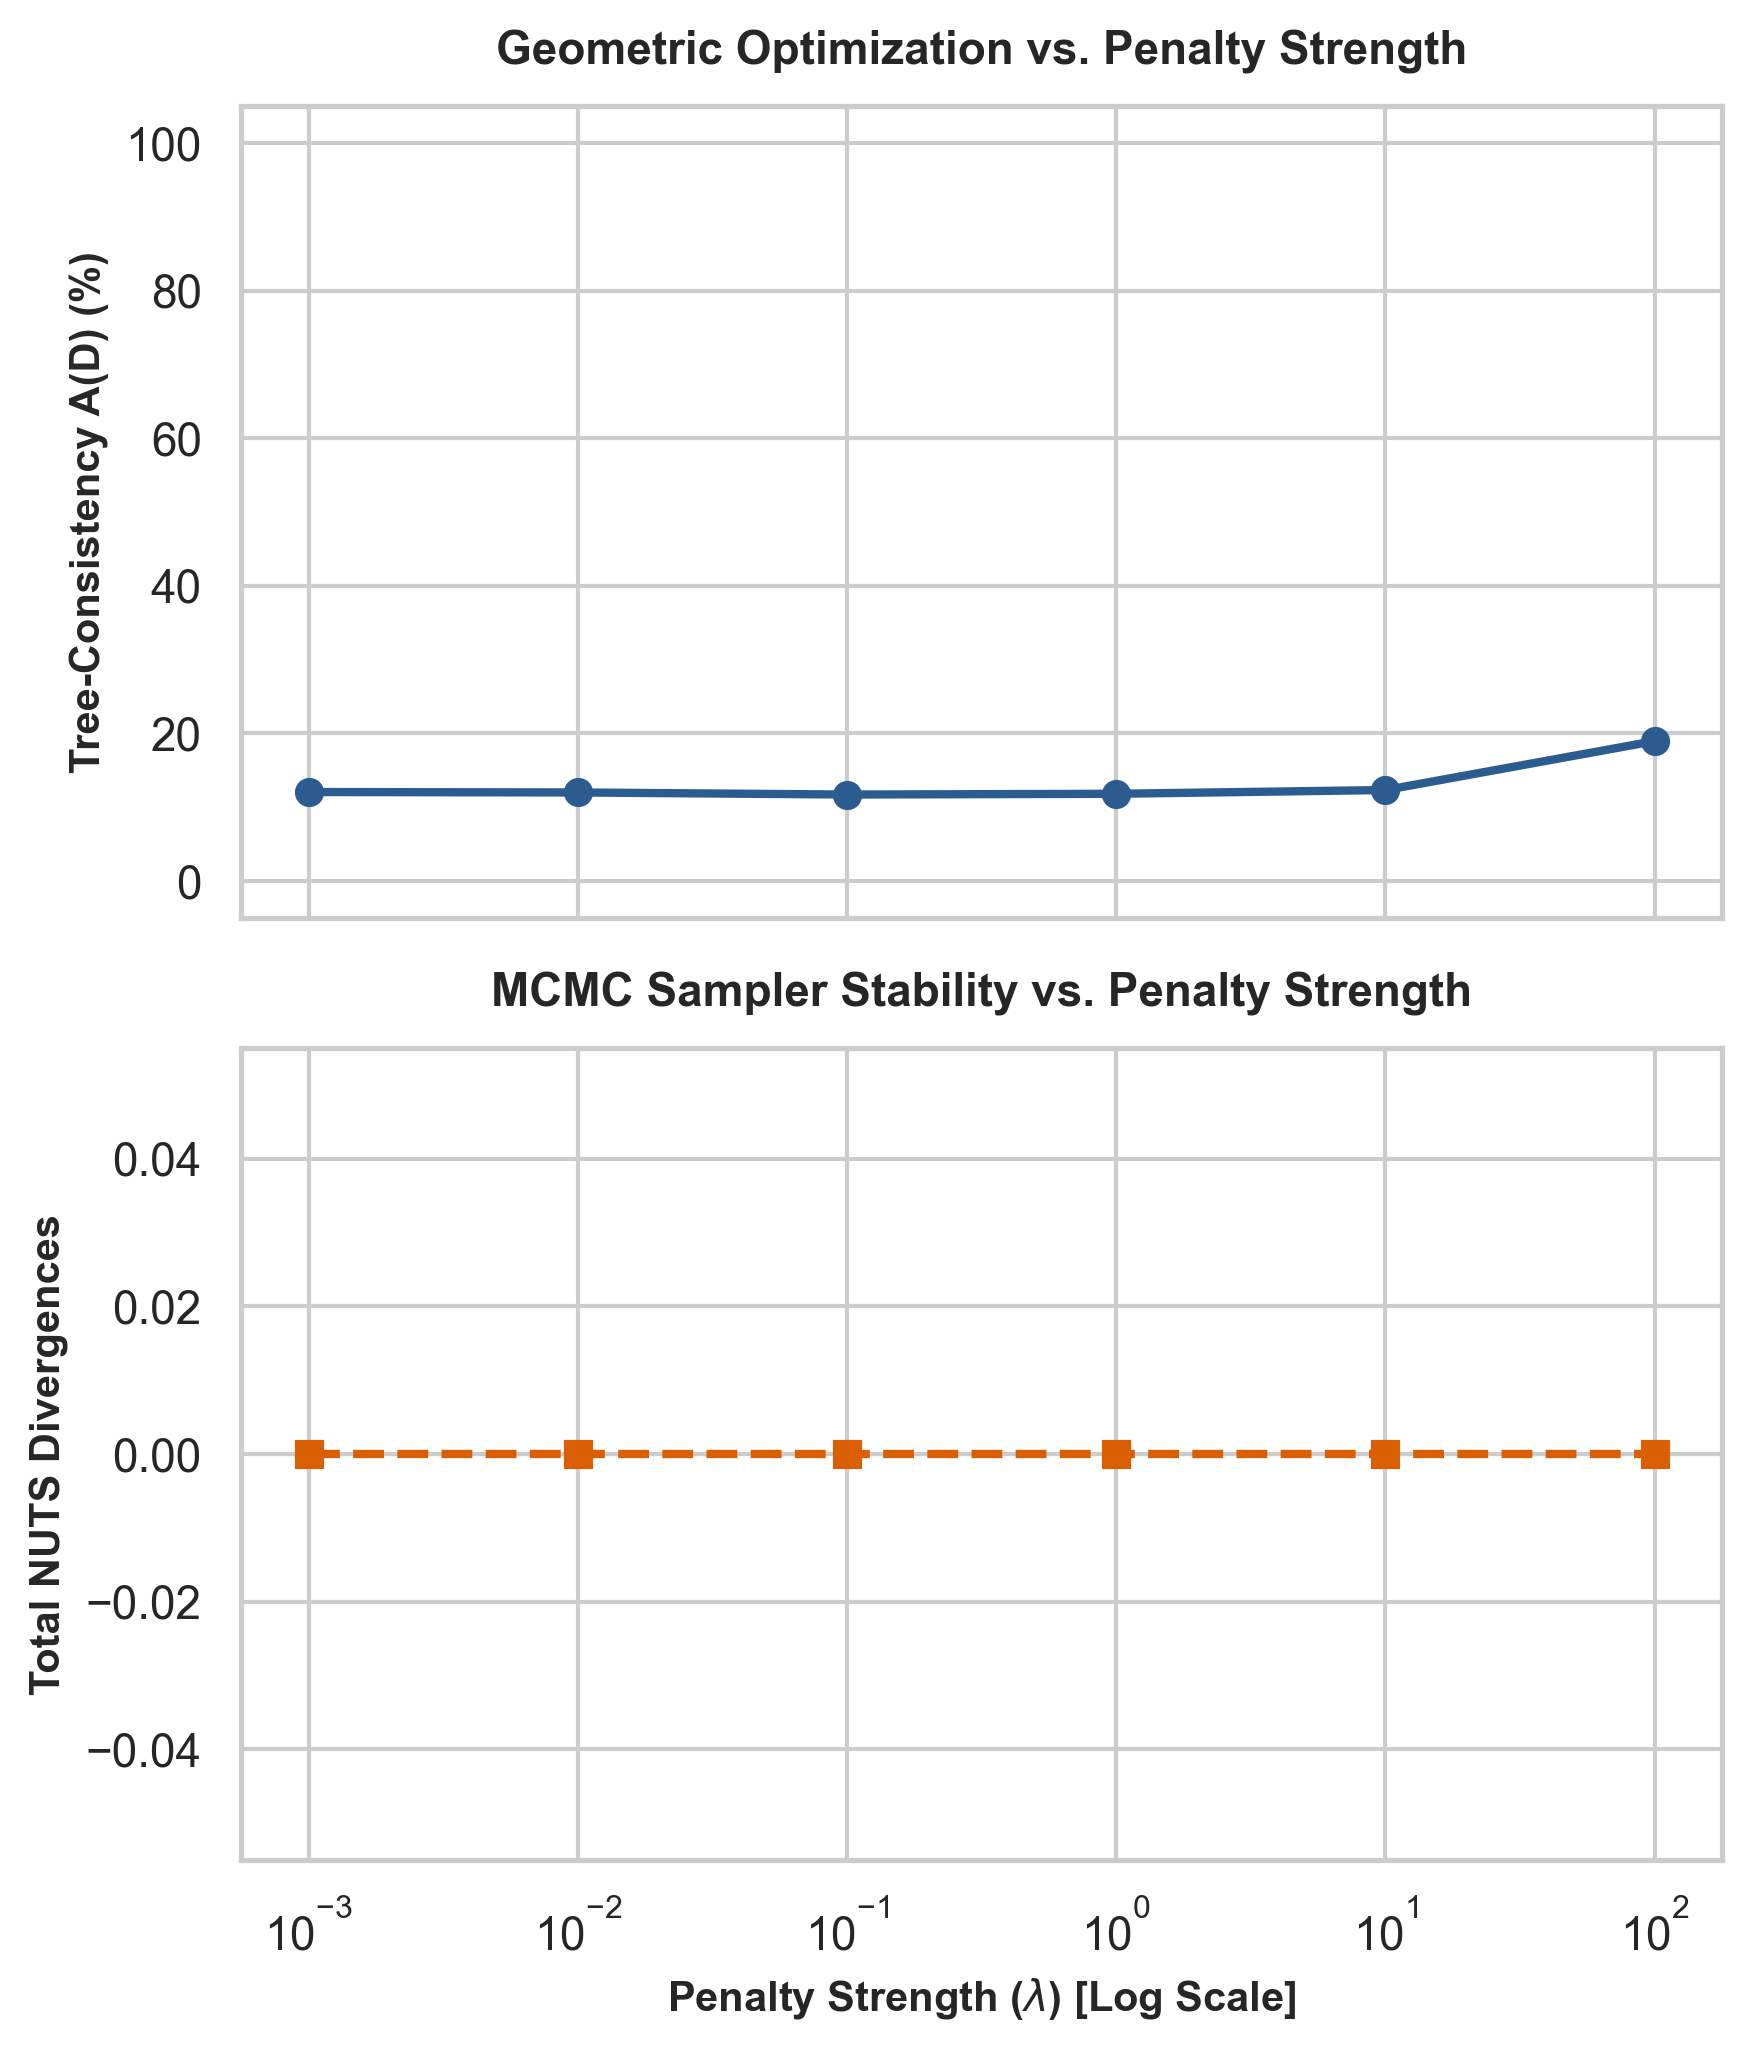

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean academic plotting style
sns.set_theme(style="whitegrid")

# Create a figure with 2 subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, dpi=300)

# Cleanly convert string percentages (e.g., "85.20%") back to regular numbers for plotting
consistency_rates = df_2['Tree_Consistency_Rate'].str.rstrip('%').astype('float')

# ---------------------------------------------------------
# SUBPLOT 1: Geometric Success (Tree Consistency)
# ---------------------------------------------------------
ax1.plot(df_2['lambda'], consistency_rates, color='#2b5c8f', marker='o', linewidth=2)
ax1.set_ylabel('Tree-Consistency A(D) (%)', fontsize=10, fontweight='bold')
ax1.set_title('Geometric Optimization vs. Penalty Strength', fontsize=11, fontweight='bold', pad=10)
ax1.set_ylim(-5, 105) # Keeps the 0-100% bounds clean

# ---------------------------------------------------------
# SUBPLOT 2: Computational Strain (Sampler Divergences)
# ---------------------------------------------------------
ax2.plot(df_2['lambda'], df_2['NUTS_Divergences'], color='#d95f02', marker='s', linewidth=2, linestyle='--')
ax2.set_xlabel(r'Penalty Strength ($\lambda$) [Log Scale]', fontsize=10, fontweight='bold')
ax2.set_ylabel('Total NUTS Divergences', fontsize=10, fontweight='bold')
ax2.set_title('MCMC Sampler Stability vs. Penalty Strength', fontsize=11, fontweight='bold', pad=10)

# Since we are using a log scale grid, force the x-axis to log formatting
ax2.set_xscale('log')

# Tighten layout spacing and save for Overleaf
plt.tight_layout()
plt.savefig('simple_lambda_diagnostics.png', bbox_inches='tight')
plt.show()